# Analyze Baselines

In [60]:
from pathlib import Path
import json

import pandas as pd

In [61]:
from temp import (
    temp_metrics,
    plot_temp_consistency,
)

## Load Original Flows

In [62]:
# Configuration
# dataset = "aitv2"
# scenario = "santos"
# test_scenario = "santos"
# attack_start = pd.Timestamp("2022-01-17 11:00")
# attack_end   = pd.Timestamp("2022-01-17 12:00")

# out_dir = Path(f"../reports/{dataset}/{scenario}/baselines")
# out_dir.mkdir(parents=True, exist_ok=True)

In [63]:
# Cross-scenario config
scenario = "santos_fox"
test_scenario = "fox"

attack_start = pd.Timestamp("2022-01-18 11:59")
attack_end   = pd.Timestamp("2022-01-18 13:15")

In [64]:
df = pd.read_csv(
    f"../data/interim/{dataset}/{test_scenario}/flows_labeled/all_flows_labeled.csv"
)

df = df.sort_values("start_time").reset_index(drop=True)

In [65]:
df["start_time_dt"] = pd.to_datetime(df["start_time_dt"], errors="coerce")

phase_bounds = (
    df
    .groupby('phase')['start_time_dt']
    .agg(['min', 'max'])
)

phase_starts = phase_bounds['min'].to_dict()

In [66]:
phase_bounds

,min,max
phase,,
0,2022-01-15 00:00:00.869369984,2022-01-19 23:59:59.055074930
1,2022-01-15 00:00:03.117595911,2022-01-17 09:04:47.678828955
2,2022-01-18 11:59:14.508178949,2022-01-18 12:37:48.927057981
3,2022-01-18 12:38:00.677339077,2022-01-18 12:38:27.806564093
4,2022-01-18 12:38:29.550966024,2022-01-18 13:13:29.431076050


## Temp Plots and Custom Metrics

In [67]:
models = [
    "multiclass",
    # "ensemble",
]

file_paths = []

for model in models:
    folder = Path(f"../experiments/{dataset}/{scenario}/baselines/{model}/metrics/")
    file_paths.extend(list(folder.iterdir()))

print(len(file_paths))

1


Processing multiclass_aug_w10_full...
Saving plot to ../reports/aitv2/santos_fox/baselines/temp_plots/multiclass_aug_w10_full.png...


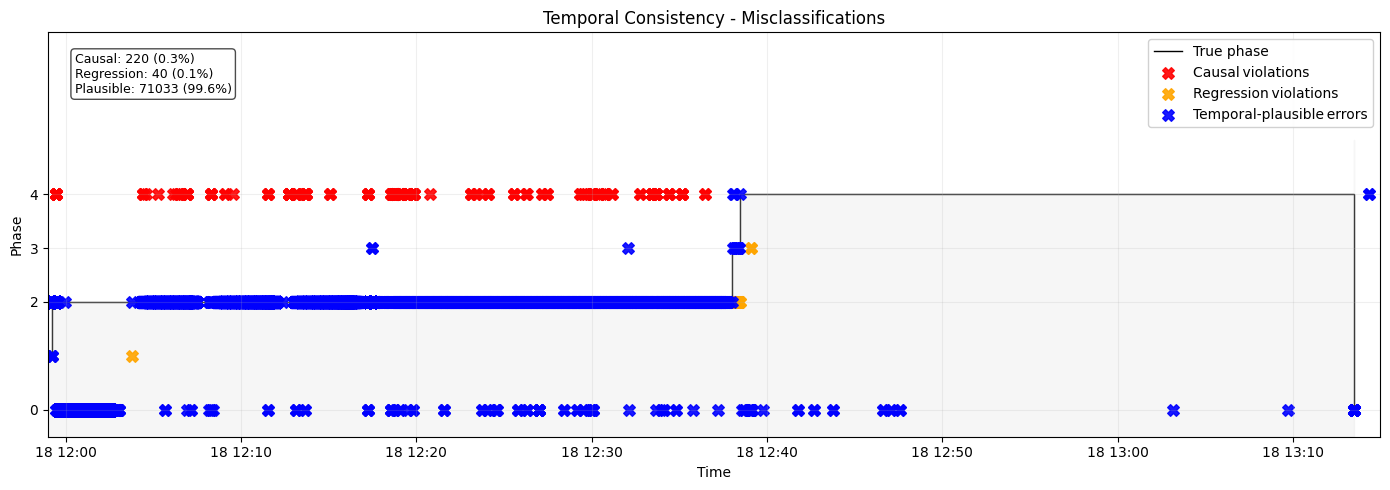

In [68]:
results = []

for file_path in file_paths:

    with open(file_path) as f:
        metrics = json.load(f)

    experiment_name = file_path.stem

    if "multiclass" in experiment_name:
        model = "multiclass"
    elif "ensemble" in experiment_name:
        model = "ensemble"
    
    if not ("aug" and "full") in experiment_name:
        continue

    print(f"Processing {experiment_name}...")

    # --- Load misclassification info ---
    real_flow_indices = metrics["real_flow_indices"]
    misclassified = df.iloc[real_flow_indices].copy()
    misclassified["y_true"] = metrics["y_true"]
    misclassified["y_pred"] = metrics["y_pred"]

    # --- Compute violation categories ---
    f1 = metrics["Macro F1"]
    wrong, causal, regression, plausible, temp_metrics_dict = temp_metrics(misclassified, f1, phase_starts)

    # --- Collect everything ---
    results.append({
        "model": f"{experiment_name}",
        "accuracy": metrics["Accuracy"],
        "precision" : metrics["Macro Precision"],
        "recall" : metrics["Macro Recall"], 
        "f1": metrics["Macro F1"],
        "FPR": metrics["False Alarm Rate"],
        "FNR": metrics["Detection Rate"],
        "total_wrong": temp_metrics_dict["total_wrong"],
        "num_causal": temp_metrics_dict["num_causal"],
        "num_regression": temp_metrics_dict["num_regression"],
        "num_plausible": temp_metrics_dict["num_plausible"],
        "causal_rate": temp_metrics_dict["causal_rate"],
        "regression_rate": temp_metrics_dict["regression_rate"],
        "plausible_rate": temp_metrics_dict["plausible_rate"],
        "temp_score": temp_metrics_dict["temp_score"]
    })

    plot_dir = out_dir / "temp_plots"
    plot_dir.mkdir(parents=True, exist_ok=True)

    # Create plots
    plot_temp_consistency(
        df, 
        phase_bounds, 
        causal,
        regression,
        plausible,
        temp_metrics_dict,
        exp_name=experiment_name, 
        out_dir = plot_dir,
        attack_start=attack_start,
        attack_end=attack_end,
        save_plot=True,
        show_plot=False
    )

## Create Metrics File

In [69]:
results_df = pd.DataFrame(results)

In [70]:
results_df_sorted_f1 = results_df.sort_values("f1", ascending=False)

# Save metrics to file
results_df_sorted_f1.to_csv(
    f"{out_dir}/metrics.csv",
    index=False
)

In [71]:
results_df_sorted_f1.head(10)

,model,accuracy,precision,recall,f1,FPR,FNR,total_wrong,num_causal,num_regression,num_plausible,causal_rate,regression_rate,plausible_rate,temp_score
0,multiclass_aug_w10_full,0.848489,0.527533,0.602195,0.535238,0.102994,0.577185,71293,220,40,71033,0.003086,0.000561,0.996353,0.533583


In [72]:
results_df_sorted_temp = results_df.sort_values("temp_score", ascending=False)

results_df_sorted_temp.head(10)

,model,accuracy,precision,recall,f1,FPR,FNR,total_wrong,num_causal,num_regression,num_plausible,causal_rate,regression_rate,plausible_rate,temp_score
0,multiclass_aug_w10_full,0.848489,0.527533,0.602195,0.535238,0.102994,0.577185,71293,220,40,71033,0.003086,0.000561,0.996353,0.533583
